In [1]:
%load_ext autoreload
%autoreload 2

from noise import *
from pathlib import Path 
import json
from data import *
from trackers import *
from main import *

from networks.conditioning import *

/mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

def load_args(name, step="last", log=True, dataloaders=False):
    """ Load an experiment with a given name. step can be an integer, "best", or "last" (default). """
    exp_dir = Path("models") / name

    with open(exp_dir / "args.json") as f:
        args_dict = json.load(f)

    return args_dict


def load_exp(name, step="last", log=True, dataloaders=False):
    """ Load an experiment with a given name. step can be an integer, "best", or "last" (default). """
    exp_dir = Path("models") / name

    with open(exp_dir / "args.json") as f:
        args_dict = json.load(f)

    ctx = TrainingContext(**args_dict, step=step, key_remap=None, seed=None, dataloaders=dataloaders, writer=False)
    if log:
        print(f"{name}: retrieved model at step {ctx.step}")

    # Disable DataParallel (needed for Hessian computation)
    ctx.model.network = ctx.model.network.module

    # Put in eval mode and disable gradients with respect to all parameters.
    ctx.model.eval()
    for p in ctx.model.parameters():
        p.requires_grad = False

    # Normalize energies.

    return ctx



In [3]:
args = load_args("multigpu/energy_inp_anisotropic_newloss_tinbox_songSMall_anisoEmb_groupNorm_lambda1_2000warmup", step = "best")
step = "last"
ctxs = {
    # "denoiser-anisotropic-newloss-tinbox": load_exp("test_mult_anisotropic_newloss_tinbox", step = "last"),
    # "denoiser-anisotropic-oldloss": load_exp("test_mult_anisotropic_oldloss", step = "last"),
    "energy-reg": load_exp("multigpu/energy_inp_anisotropic_newloss_tinbox_songSMall_anisoEmb_groupNorm_lambda1_2000warmup", step = step),
    "energy-non-reg": load_exp("multigpu/energy_inp_anisotropic_newloss_tinbox_songSmall_anisoEmb_groupNorm_lambda0_lr1e-4_2000warmup", step = step),
    # "denoiser-anisotropic-newloss-tinbox": load_exp("test_denoiser_mult_anisotropic_newloss_newTweedie_tinbox_song_groupNorm", step = "last"),
    # "energy-anisotropic-newloss": load_exp("test_energy_mult_anisotropic_newloss_newTweedie_tinbox_song_groupNorm", step = "last"),
}

default_ctx = ctxs["energy-reg"]
device = default_ctx.device
dataset_info = default_ctx.dataset_info
d = dataset_info.dimension


# Load data
test_batch_size = 32
CHW = 3 * 32 * 32
H = 32

train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=args["horizontal_flip"], data_subset=eval(args["data_subset"]),
    train_batch_size=test_batch_size, test_batch_size=test_batch_size, num_workers=args["num_workers"], seed=2
)

images = next(iter(test_dataloader))  # load for testing things.

shape = (images[0].shape[0], CHW)

time_tracker: TimeTracker = TimeTracker()
time_tracker.switch("initialization")

min_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["min_noise_level"]) # This calls denoising error
max_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["max_noise_level"])
noise_level_sampler: NoiseLevelSampler = eval(args["noise_level_sampler"])(min=min_noise_level, max=max_noise_level)

covariance = spatial_corr_covariance(spatial_size=shape[-2], box_size=12, var_box=1, device=device, var_clean=1e-3)
noisy_sampler = MultipleColoredGaussianSamplerWithInput(noise_covariance=covariance)
# noisy_sampler = MultipleColoredGaussianSampler()

scale_noise_level = 1
num_variances = 17
psnr_min = -30
psnr_max = 90
psnrs = torch.linspace(psnr_min, psnr_max, num_variances , device=default_ctx.device)  # (L,), steps of 7.5dB
noise_levels = DenoisingError(dataset_info=default_ctx.dataset_info, psnr=psnrs).to_noise_level().variance  # (L,)
denoising_error_all_scales = torch.zeros(num_variances)
energy_denoising_error_all_scales = torch.zeros(num_variances)

multigpu/energy_inp_anisotropic_newloss_tinbox_songSMall_anisoEmb_groupNorm_lambda1_2000warmup: retrieved model at step 50000
multigpu/energy_inp_anisotropic_newloss_tinbox_songSmall_anisoEmb_groupNorm_lambda0_lr1e-4_2000warmup: retrieved model at step 15000


In [15]:
def compute_norm_mse(ctx, test_dataloader, noise_level_sampler, noisy_sampler, time_tracker, test_batch_size=4):
    """ Compute the norm mse on a few batches of the test set. """
    norm_error = []
    log_gradients = ctx.args.log_gradients
    if log_gradients:
        gradients_tracker = defaultdict(MeanTracker)  # We directly compute summed gradients for efficiency.
        param_dict = ctx.network.my_named_parameters(reduced=True, with_grad=True)

    with torch.set_grad_enabled(log_gradients):
        for i, batch in enumerate(noisy_loader(test_dataloader, noise_level_sampler, ctx.noisy_sampler, ctx.time_tracker), start=1):
            ctx.time_tracker.switch("evaluation")

            # NOTE: we could set up hooks to record statistics of activations.
            input = ModelInput(noisy=batch.noisy, noise_level=batch.noise_level, covariance=batch.noise_covariance)  # (B, C, H, W)
            output: ModelOutput = ctx.model(input, create_graph=True)  # (B, C, H, W)

            # Update tracker metrics.
            z = apply_power_to_list_covariances(batch.noise_covariance, batch.noisy - batch.clean, p=-1)
            phi_inv = get_inv_tensor_from_list_covariances(batch.noise_covariance).unsqueeze(1)
            phi_inv_minus_z = 0.5 * (phi_inv - z ** 2)
            e = output.noise_score - phi_inv_minus_z
            metrics = torch.mean(e ** 2, dim=(-1, -2, -3))
            norm_error.append(metrics)
            if i == 7:  # Cannot be zero (this function is not called otherwise)
                break

    norm_error = torch.cat(norm_error, dim=0)
    return norm_error

In [ ]:
norm_error_all_scales = torch.zeros(num_variances)
for idx in range(num_variances):
        covariance = spatial_corr_covariance(spatial_size=H, box_size=12, var_box=noise_levels[idx] * scale_noise_level, device=device, var_clean = 1e-3 * scale_noise_level)
        noisy_sampler = MultipleColoredGaussianSamplerWithInput(noise_covariance=covariance)

        metrics = compute_norm_mse(ctxs["energy-reg"], test_dataloader, noise_level_sampler, noisy_sampler, time_tracker)
        norm_error_all_scales[idx] = metrics.mean().item()

In [8]:
norm_error_all_scales, norm_error_all_scales_reg

(tensor([1.1065e+11, 2.3001e+11, 1.8206e+11, 1.5283e+11, 1.5550e+11, 2.0537e+11,
         1.4535e+11, 1.4299e+11, 1.2254e+11, 1.8622e+11, 8.2120e+10, 2.8259e+11,
         8.0102e+10, 1.6635e+11, 1.1492e+11, 2.3046e+11, 8.1010e+10]),
 tensor([0.2081, 0.2082, 0.2060, 0.2096, 0.2104, 0.2093, 0.2066, 0.2093, 0.2096,
         0.2065, 0.2073, 0.2094, 0.2088, 0.2074, 0.2059, 0.2074, 0.2065]))

In [ ]:
sampler = 'ColoredGaussian'
type_cov = 'box_inp'  # 'sequential', 'random', 'uniform', 'uniform_2'
shape = (images[0].shape[0], CHW)

time_tracker: TimeTracker = TimeTracker()
time_tracker.switch("initialization")

min_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["min_noise_level"]) # This calls denoising error
max_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["max_noise_level"])
noise_level_sampler: NoiseLevelSampler = eval(args["noise_level_sampler"])(min=min_noise_level, max=max_noise_level)

noisy_sampler = ColoredGaussianSampler(shape = shape[1])

for batch in noisy_loader(train_dataloader, noise_level_sampler, noisy_sampler, time_tracker, type_cov = type_cov):

    input = ColoredModelInput(noisy=batch.noisy, cov=batch.cov)
    break

In [91]:
output = ctxs['energy-seq'].model.forward(batch, create_graph=True, compute_scores = True)
output_uniform = ctxs['energy-scalar'].model.forward(batch, create_graph=True, compute_scores = True)
output_uniform_2scales = ctxs['energy-scalarx2'].model.forward(batch, create_graph=True, compute_scores = True)
output_uniform_2scales_0p1 = ctxs['energy-scalarx2-reg0p01'].model.forward(batch, create_graph=True, compute_scores = True)
output_random = ctxs['energy-random'].model.forward(batch, create_graph=True, compute_scores = True)
output_box = ctxs['energy-box'].model.forward(batch, create_graph=True, compute_scores = True)
output_random_denoiser = ctxs['denoiser'].model.forward(batch, create_graph=True)

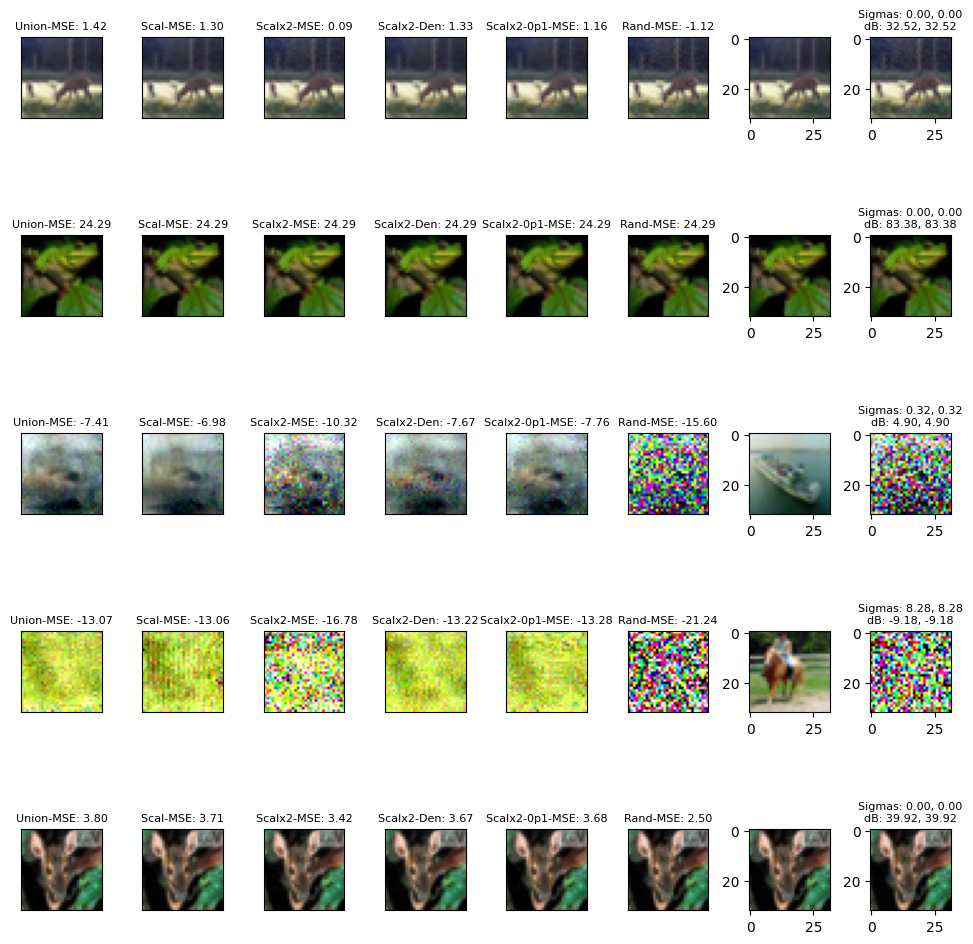

In [92]:
# idx = 0
# fig, ax = plt.subplots(1, 4, figsize=(10, 10))
# ax[0].imshow(output.denoised[idx].view(3, 32, 32).permute(1, 2, 0).detach().cpu().numpy())
# ax[0].set_title('Denoised Image')
# ax[1].imshow(output_uniform.denoised[idx].view(3, 32, 32).permute(1, 2, 0).detach().cpu().numpy())
# ax[1].set_title('Uniform Denoised Image')
# ax[2].imshow(output_random.denoised[idx].view(3, 32, 32).permute(1, 2, 0).detach().cpu().numpy())
# ax[2].set_title('Random Denoised Image')
# ax[3].imshow(batch.clean[idx].permute(1, 2, 0).detach().cpu().numpy())
# ax[3].set_title('Clean Image')
# plt.tight_layout()
# print(batch.cov.get_diag()[idx])

num_show_imgs = 5
fig, ax = plt.subplots(num_show_imgs, 8, figsize=(12, 12))
# Add title to each column
ax[0, 0].set_title('Denoised Image (Energy)')
ax[0, 1].set_title('Denoised Image (Uniform)')
ax[0, 2].set_title('Denoised Image (Uniform 2 Scales)')
ax[0, 3].set_title('Denoised Image (Random)')
ax[0, 4].set_title('Clean Image')
for i in range(num_show_imgs):
    # ax[i, 0].imshow(np.clip(output.denoised[i].view(3, 32, 32).permute(1, 2, 0).detach().cpu().numpy(), 0, 1))
    # denoising_error = (output.denoised[i] - batch.clean[i].view(-1)).norm().item()
    # ax[i, 0].set_title(f'Seq-MSE: {-10 * np.log10(denoising_error):.2f}', fontsize=8)
    ax[i, 0].imshow(np.clip(output_box.denoised[i].view(3, 32, 32).permute(1, 2, 0).detach().cpu().numpy(), 0, 1))
    denoising_error = (output_box.denoised[i] - batch.clean[i].view(-1)).norm().item()
    ax[i, 0].set_title(f'Union-MSE: {-10 * np.log10(denoising_error):.2f}', fontsize=8)
    ax[i, 1].imshow(np.clip(output_uniform.denoised[i].view(3, 32, 32).permute(1, 2, 0).detach().cpu().numpy(), 0, 1))
    denoising_error_uniform = (output_uniform.denoised[i] - batch.clean[i].view(-1)).norm().item()
    ax[i, 1].set_title(f'Scal-MSE: {-10 * np.log10(denoising_error_uniform):.2f}', fontsize=8)
    ax[i, 2].imshow(np.clip(output_uniform_2scales.denoised[i].view(3, 32, 32).permute(1, 2, 0).detach().cpu().numpy(), 0, 1))
    denoising_error_uniform_2scales = (output_uniform_2scales.denoised[i] - batch.clean[i].view(-1)).norm().item()
    ax[i, 2].set_title(f'Scalx2-MSE: {-10 * np.log10(denoising_error_uniform_2scales):.2f}', fontsize=8)
    ax[i, 3].imshow(np.clip(output_random_denoiser.denoised[i].view(3, 32, 32).permute(1, 2, 0).detach().cpu().numpy(), 0, 1))
    denoising_error_random_denoiser = (output_random_denoiser.denoised[i].view(-1) - batch.clean[i].view(-1)).norm().item()
    ax[i, 3].set_title(f'Scalx2-Den: {-10 * np.log10(denoising_error_random_denoiser):.2f}', fontsize=8)
    ax[i, 4].imshow(np.clip(output_uniform_2scales_0p1.denoised[i].view(3, 32, 32).permute(1, 2, 0).detach().cpu().numpy(), 0, 1))
    denoising_error_uniform_2scales_0p1 = (output_uniform_2scales_0p1.denoised[i] - batch.clean[i].view(-1)).norm().item()
    ax[i, 4].set_title(f'Scalx2-0p1-MSE: {-10 * np.log10(denoising_error_uniform_2scales_0p1):.2f}', fontsize=8)
    ax[i, 5].imshow(np.clip(output_random.denoised[i].view(3, 32, 32).permute(1, 2, 0).detach().cpu().numpy(), 0, 1))
    denoising_error_random = (output_random.denoised[i] - batch.clean[i].view(-1)).norm().item()
    ax[i, 5].set_title(f'Rand-MSE: {-10 * np.log10(denoising_error_random):.2f}', fontsize=8)
    ax[i, 6].imshow(np.clip(batch.clean[i].permute(1, 2, 0).detach().cpu().numpy(), 0, 1))
    ax[i, 7].imshow(np.clip(batch.noisy[i].permute(1, 2, 0).detach().cpu().numpy(), 0, 1))
    if type_cov == 'random' or type_cov == 'box_inp':
        ax[i, 7].set_title(f'Sigmas:{np.max(batch.cov.get_diag()[i].cpu().numpy()):.2f}, {np.min(batch.cov.get_diag()[i].cpu().numpy()):.2f}\n'
                           f'dB :{-10 * np.log10(np.max(batch.cov.get_diag()[i].cpu().numpy())):.2f}, {-10 * np.log10(np.min(batch.cov.get_diag()[i].cpu().numpy())):.2f}',
                           fontsize=8)
    else:
        ax[i, 7].set_title(
            f'Sigmas: {batch.cov.get_diag()[i][0].cpu().numpy():.2f}, {batch.cov.get_diag()[i][-1].cpu().numpy():.2f}\n'
            f'dB: {-10 * np.log10(batch.cov.get_diag()[i][0].cpu().numpy()):.2f}, {-10 * np.log10(batch.cov.get_diag()[i][-1].cpu().numpy()):.2f}',
            fontsize=8
        )

    for j in range(6):
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])
    plt.subplots_adjust(wspace=0.5, hspace=0.5)
    # print(batch.cov.get_diag()[i])